


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados. Precisamos usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados


## Plano de solução

Li e imprimi todos os arquivos, usando um teste inicial com print() na mesma célula de leitura (depois deletei o teste para deixar o código mais limpo), para verificar quais são os separadores e se existe coluna com titulo ausente. Tomei bastante cuidado para dar nomes descritivos aos DataFrames. Em seguida, imprimi as informações gerais de cada um, para já ter uma idéia dos problemas a serem resolvidos na Etapa 2, como dados ausentes.

In [1]:
# bibliotecas
import pandas as pd  # Importando a biblioteca pandas
from matplotlib import pyplot as plt # Importando o recurso gráfico pyplot da biblioteca matplotlib

In [2]:
# Lendo o DataFrane orders, do caminho '/datasets/instacart_orders.csv':
orders = pd.read_csv('../datasets/instacart_orders.csv',sep = ';') # É necessitario o uso do separador ';'

# Lendo o DataFrane products, do caminho '/datasets/products.csv':
products = pd.read_csv('../datasets/products.csv',sep = ';') # É necessitario o uso do separador ';'

# Lendo o DataFrane order_products, do caminho '/datasets/order_products.csv':
order_products = pd.read_csv('../datasets/order_products.csv',sep = ';') # É necessitario o uso do separador ';'

# Lendo o DataFrane aisles, do caminho '/datasets/aisles.csv':
aisles = pd.read_csv('../datasets/aisles.csv',sep = ';') # É necessitario o uso do separador ';'

# Lendo o DataFrane departments, do caminho '/datasets/departments.csv':
departments = pd.read_csv('../datasets/departments.csv',sep = ';') # É necessitario o uso do separador ';'

In [3]:
# Imprimindo as informações sobre o DataFrame 'instacart_orders':
orders.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
# Imprimindo as informações sobre o DataFrame 'products':
products.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     49694 non-null  object 
 1   product_name   48311 non-null  object 
 2   aisle_id       49569 non-null  float64
 3   department_id  49569 non-null  float64
dtypes: float64(2), object(2)
memory usage: 1.5+ MB


In [5]:
# Imprimindo as informações sobre o DataFrame 'order_products':
order_products.info(show_counts=True) # é necessário passar o parâmetro show_counts=True

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [6]:
# Imprimindo as informações sobre o DataFrame 'aisles':
aisles.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [7]:
# Imprimindo as informações sobre o DataFrame 'departments':
departments.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


## Conclusões

Observei que todos os arquivos csv apresentados usam ' ; ' como separador. Ao observar as informações gerais, também notei a presença de dados ausentes nas colunas: 'days_since_prior_order' de 'instacart_orders', 'product_name' de 'products', e 'add_to_cart_order' de 'order_products'. Também é possivel verificar os tipos de dados de cada coluna dos DataFrames, para futuramente tratar esses dados.

# Etapa 2. Preparação de dados

## Plano de solução

Desejo verificar os duplicados, e em seguida os valores ausentes, de cada DataFrame

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [8]:
# Verificar se há pedidos duplicados
print(f'há {orders.duplicated().sum()} pedidos duplicados em orders') # Verificando a quantidade total de linhas duplicadas com os métodos duplicated() e sum()
print()
print(orders[orders.duplicated()]) # Filtrando as linhas duplicadas para analisar o que elas tem em comum

há 15 pedidos duplicados em orders

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   128674

É possível verificar que existem 15 linhas duplicadas, e todos eles foram feitos na Quarta Feira (3) e às 2 horas da manhã

In [9]:
# Com base nas conclusões,

# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras
print(orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

O que esse resultado quer dizer?

Temos 121 pedidos feitos às 2h da manhã nas quartas-feiras

In [10]:
# Removendo pedidos duplicados
orders = orders.drop_duplicates()

In [11]:
# Verificando as linhas duplicadas mais uma vez
print(orders.duplicated().sum())

0


Agora não temos mais nenhuma linha duplicada

In [12]:
# Verificando novamente apenas os IDs de pedidos duplicados
print(orders['order_id'].duplicated().sum())

0


Não temos nenhuma linha com duplicados na coluna dos IDs ( 'order_id' )



Descreva brevemente suas conclusões e o que você fez com elas.

Não temos mais nenhum duplicado expliscito

### DataFrame `products`

In [13]:
# Verificando se há linhas completamente duplicadas
print(products.duplicated().sum())

0


Não temos linhas completamente duplicadas no DataFrame 'products'

In [14]:
# Verificando apenas IDs dos produtos duplicados
print(products['product_id'].duplicated().sum())

0


Não temos duplicados na coluna de IDs 'product_id'

In [15]:
# Verificando apenas nomes de produtos duplicados (convertendo os nomes para minúsculas para uma comparação melhor)
# Convertendo os nomes para minusculo:
products['product_name'] = products['product_name'].str.lower()
# Verificando os produtos duplicados com um filtro sobre a coluna dos nomes:
print(products['product_name'][products['product_name'].duplicated()])

71                                                   NaN
104                                                  NaN
109                                                  NaN
217                                                  NaN
296                                                  NaN
                              ...                       
49689                      high performance energy drink
49690                      original pancake & waffle mix
49691    organic instant oatmeal light maple brown sugar
49692                             spring water body wash
49693                            burrito- steak & cheese
Name: product_name, Length: 1486, dtype: object


Temos 1361 valores duplicados nos nomes. Esses são duplicados do tipo categórico.

In [16]:
# Descartando os valores NaN, queremos verificar os nomes dos produtos duplicados.
# Faremos isso, filtrando o DataFrame 'products', na coluna 'product_name', com base em duas condições lógicas (nomes duplicados e não ausentes),e imprimindo o resultado:
print(products['product_name'][(products['product_name'].duplicated()) & (~products['product_name'].isna())])

2058                                     biotin 1000 mcg
5455                    green tea with ginseng and honey
5558                              cream of mushroom soup
7558                           cinnamon rolls with icing
9037                              american cheese slices
                              ...                       
49689                      high performance energy drink
49690                      original pancake & waffle mix
49691    organic instant oatmeal light maple brown sugar
49692                             spring water body wash
49693                            burrito- steak & cheese
Name: product_name, Length: 104, dtype: object


Dentre todos os 1361 nomes duplicados, apenas 104 deles não são valores ausentes. Ou seja, temos apenas 104 nomes duplicados, na realidade.

conclusões:

Temos que nos atentar a esses valores ausentes da coluna 'product_name', pois só 104 duplicados nos interessam

### DataFrame `departments`

In [17]:
# Verificando se há linhas completamente duplicadas
print(departments.duplicated().sum())

0


Não temos linhas completamente duplicadas no DataFrame 'departments'

In [18]:
# Verificando apenas se há IDs dos produtos duplicados
print(departments['department_id'].duplicated().sum())

0


Descreva brevemente suas conclusões e o que você fez com elas.

Não existem duplicados em departments

### DataFrame `aisles`

In [19]:
# Verificando se há linhas completamente duplicadas
print(aisles.duplicated().sum())

0


Não temos linhas completamente duplicadas no DataFrame 'aisles'

In [20]:
# Verificando apenas se há IDs dos produtos duplicados
print(aisles['aisle_id'].duplicated().sum())

0


Descreva brevemente suas conclusões e o que você fez com elas.

Não temos duplicados em aisles

### DataFrame `order_products`

In [21]:
# Verificando se há linhas completamente duplicadas
print(order_products.duplicated().sum())

0


Não temos linhas completamente duplicadas no DataFrame 'order_products'

In [22]:
# Verificando se há duplicados nos IDs de cada pedido:
print('IDs de PEDIDOS duplicados:')
print(order_products[order_products['order_id'].duplicated()])

IDs de PEDIDOS duplicados:
         order_id  product_id  add_to_cart_order  reordered
367       2867619       48094                9.0          0
824        844425       39408               10.0          1
1124      3319857       37067               19.0          0
1258      1038788       12471               14.0          0
1303      2825714       44632               16.0          1
...           ...         ...                ...        ...
4545002    577211       15290               12.0          1
4545003   1219554       21914                9.0          0
4545004    692640       47766                4.0          1
4545005    319435         691                8.0          1
4545006   1398151       28733                9.0          0

[4094961 rows x 4 columns]


conclusões:

Existem 4094961 IDs de pedidos duplicados.

## Encontrando e removendo valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [23]:
# Encontrando valores ausentes na coluna 'product_name'
print(products[products['product_name'].isna()])

                                              product_id product_name  \
37                                                    38          NaN   
71                                                    72          NaN   
104    105;"Easy Grab 9\""x13\"" Oblong Glass Bakewar...          NaN   
109                                                  110          NaN   
217                   218;"6\"" Organic Carrot Cake";8;3          NaN   
...                                                  ...          ...   
49552                                              49553          NaN   
49574                                              49575          NaN   
49640                                              49641          NaN   
49663                                              49664          NaN   
49668                                              49669          NaN   

       aisle_id  department_id  
37        100.0           21.0  
71        100.0           21.0  
104         NaN         

conclusões:

Temos 1258 valores ausentes na coluna 'product_name'. Eles são do tipo categórico

In [24]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
# farei uma máscara Booleana multicondicional para verificar se os valores ausentes em 'product_name' com ID = 100 são iguais à 1258.caso o contrário, a resposta será NÃO. Aplicarei o método sum() a essa máscara para somar a quantidade de valores True: 
mascara = ((products['product_name'].isna()) & (products['aisle_id'] == 100))
print(mascara.sum())

1258


conclusões:

Percebemos, a partir da nossa máscara, que a resposta da pergunta é SIM: Todos os nomes de produtos ausentes estão associados com o corredor de ID 100, já que tivemos 1258 linhas atendendo a essa condição.

In [25]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
# A idéia é a mesma: Fazer uma máscara com ambas as condições e aplicar o método sum() para comparar a quantidade de casos com 1258:
mascara = ((products['product_name'].isna()) & (products['department_id'] == 21))
print(mascara.sum())

1258


conclusões:

A resposta da pergunta é SIM: Todos os nomes de produtos ausentes estão associados com o departamento de ID 21, já que tivemos 1258 casos.

In [26]:
# Usando as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
mascara = (products['aisle_id'] == 100) & (products['department_id'] == 21)
print(products[mascara])

      product_id product_name  aisle_id  department_id
37            38          NaN     100.0           21.0
71            72          NaN     100.0           21.0
109          110          NaN     100.0           21.0
296          297          NaN     100.0           21.0
416          417          NaN     100.0           21.0
...          ...          ...       ...            ...
49552      49553          NaN     100.0           21.0
49574      49575          NaN     100.0           21.0
49640      49641          NaN     100.0           21.0
49663      49664          NaN     100.0           21.0
49668      49669          NaN     100.0           21.0

[1258 rows x 4 columns]


conclusões:

 'aisle_id' = 100  e  'department_id' = 21 coincidem APENAS nas linhas onde 'product_name' é ausente, já que é a mesma quantidade de casos em ambas as situações: 1258

In [27]:
# Preenchendo nomes de produtos ausentes com 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
print(products['product_name'].sample(10))

28307                      loaded cheddar potato bake cups
19359    dairy free greek style vanilla coconut milk yo...
1423                 light buttermilk ranch salad dressing
36992                             chocolate flavored syrup
40124                                 face scrub- original
7326                                               Unknown
27849    fresh lemon odor shield 13 gallon tall kitchen...
25830        authentic pub cheese sharp cheddar spreadable
41084                warm & crunchy apple cinnamon granola
38746        kettle cooked sea salt & vinegar potato chips
Name: product_name, dtype: object


conclusões:

Transformamos os valores ausentes em uma categoria chamada 'Unknown'

### DataFrame `orders`

In [28]:
# Encontrando os valores ausentes
print(orders['days_since_prior_order'].isna().sum())

28817


Existem 28817 valores ausentes na coluna 'days_since_prior_order'. Eles são do tipo quantitativo

In [29]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
# Devemos investigar os casos onde 'days_since_prior_order' é NaN, e 'order_number' > 1:
mascara = ((orders['days_since_prior_order'].isna()) & (orders['order_number'] > 1))
print(mascara.sum())

0


NÃO existe nenhum valor ausente em orders para os clientes que não estão fazendo o primeiro pedido

### DataFrame `order_products`

In [30]:
# Encontrando os valores ausentes
print(order_products['add_to_cart_order'].isna().sum())

836


Temos 836 valores ausentes na coluna 'add_to_cart_order'

In [31]:
# Quais são os valores mínimo e máximo dessa coluna?
maximo_add_to_cart_order = order_products['add_to_cart_order'].max()
minimo_add_to_cart_order = order_products['add_to_cart_order'].min()
print(f'O valor máximo de "add_to_cart_order" é {maximo_add_to_cart_order}, enquanto seu valor mínimo é {minimo_add_to_cart_order}')

O valor máximo de "add_to_cart_order" é 64.0, enquanto seu valor mínimo é 1.0


conclusões:

O valor máximo de "add_to_cart_order" é 64.0, enquanto seu valor mínimo é 1.0

In [32]:
# Salvando todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
mascara = order_products['add_to_cart_order'].isna() # mascara da condição booleana: há valor ausente em 'add_to_cart_order'
cart_order_nans = order_products[mascara] # extração das linhas que satisfazem a condição da mascara booleana.
ids_cart_order_nans = cart_order_nans['order_id'].unique() # Extração da lista dos IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order', como queriamos. Salvamos essa lista na variável 'ids_cart_order_nans'
print(ids_cart_order_nans)

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [33]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
# Agrupando os pedidos com dados ausentes por ID de pedido
# Contando o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
print(cart_order_nans.groupby('order_id')['product_id'].count().min())

1


conclusões:

A resposta é NÃO. Houve pelo menos um pedido (ID) com valores ausentes em 'add_to_cart_order' que obteve APENAS 1 produto.

In [34]:
# Substituindo valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999) # substituindo os valores ausentes por 999
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype('int') # convertendo os dados da coluna 'add_to_cart_order' para inteiro
print(order_products['add_to_cart_order'].sample(5))

3342340     4
507205     23
207815      6
3821355     4
886669      4
Name: add_to_cart_order, dtype: int64


conclusões:

Substituimos os valores ausentes por um valor quantitativo inteiro: 999

## Conclusões

conclusões intermediárias da Etapa 2. Preparação de dados

detectamos e Tratamos dados ausentes e duplicados para reduzir os erros estatisticos na nossa análise futura

# Etapa 3. Análise de dados

### [A1] Verificando se os valores fazem sentido

In [35]:
print('Analisando "order_hour_of_day":')
print(f'mínimo = {orders["order_hour_of_day"].min()}; máximo = {orders["order_hour_of_day"].max()}')

Analisando "order_hour_of_day":
mínimo = 0; máximo = 23


Nenhum problema com a coluna 'order_hour_of_day'

In [36]:
print('Analisando "order_dow":')
print(f'mínimo = {orders["order_dow"].min()}; máximo = {orders["order_dow"].max()}')

Analisando "order_dow":
mínimo = 0; máximo = 6


Nenhum problema também com a coluna 'order_dow'

conclusões:

Está tudo certo com a variação das horas do dia e dos dias da semana

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

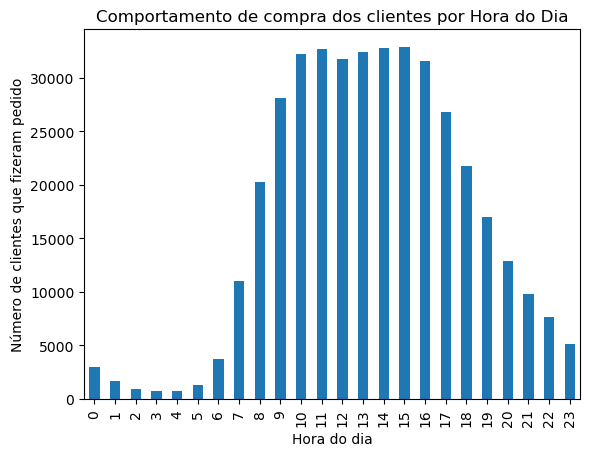

In [37]:
usuarios_por_hora = orders.groupby('order_hour_of_day')['user_id'].nunique().reset_index() # agrupando os clientes por hora do dia, e armazenando o resultado em um novo DataFrame

# Plotando um gráfico de barras
usuarios_por_hora.plot(
     x = 'order_hour_of_day',
     y = 'user_id',
    title = 'Comportamento de compra dos clientes por Hora do Dia',
    kind = 'bar',
    xlabel = 'Hora do dia',
    ylabel = 'Número de clientes que fizeram pedido',
    legend = False,
)
plt.show()

conclusões:

As pessoas costumam comprar entre as 8h da manhã e as 20h da noite, atingindo o seu pico por volta das 11h da manhã e 15h da tarde.

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

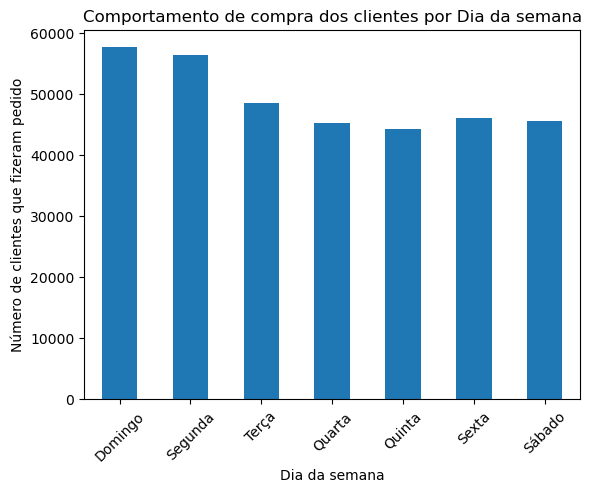

In [38]:
usuarios_por_dia = orders.groupby('order_dow')['user_id'].nunique().reset_index() # agrupando os clientes por dia da semana, e armazenando o resultado em um novo DataFrame

# Plotando um gráfico de barras:
usuarios_por_dia.plot(
    x = 'order_dow',
    y = 'user_id',
    title = 'Comportamento de compra dos clientes por Dia da semana',
    kind = 'bar',
    xlabel = 'Dia da semana',
    ylabel = 'Número de clientes que fizeram pedido',
    legend = False,
    rot = 45
)
# mudando os rótulos do eixo x:
plt.xticks([0, 1, 2, 3, 4, 5, 6], 
           ['Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado'])
plt.show()

conclusões:

Domingo e Segunda são os dias da semana em que as pessoas mais compram produtos alimentícios.

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

conclusões:

Uma grande quantidade de pessoas costuman esperar entre 6 a 8 dias para o seu próximo pedido (máximo de aproximadamente 80 mil pedidos), enquanto uma pequena quantidade de pessoas costumam esperar entre 24 e 28 dias para o seu próximo pedido (minimo de aproximadamente 6 mil pedidos).

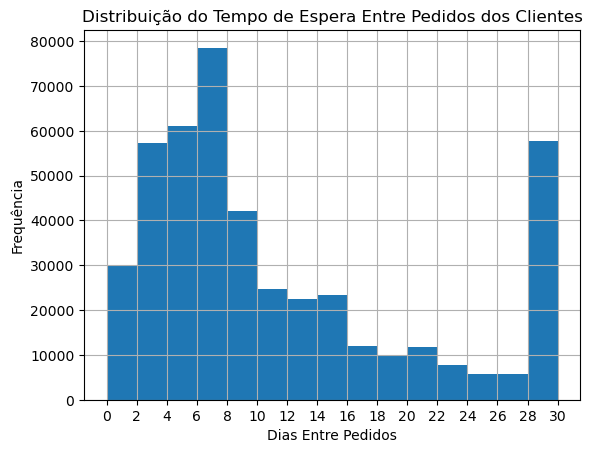

In [39]:
# construindo um histograma para analisar os dados de distribuição dos usuários para o tempo de espera:
orders.hist(column = 'days_since_prior_order', bins = 15)
plt.xlabel('Dias Entre Pedidos')
plt.ylabel('Frequência')
plt.title('Distribuição do Tempo de Espera Entre Pedidos dos Clientes')
plt.xticks(range(0, 31, 2)) # Adicionando mais rótulos no eixo x
plt.show()


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Criando gráficos de barras para ambos os dias e descrevendo as diferenças.

In [40]:
# Filtraremos os dados das quartas e sábados e armazenaremos em novos DataFrames:
orders_quarta = orders[orders['order_dow'] == 3]
orders_sabado = orders[orders['order_dow'] == 6]

In [41]:
# Agruparemos os pedidos de cada DataFrame filtrado conforme a hora do dia, e armazenaremos o resultado em novos DataFrames:
orders_quarta_horas = orders_quarta.groupby('order_hour_of_day')['order_id'].count().reset_index()
orders_sabado_horas = orders_sabado.groupby('order_hour_of_day')['order_id'].count().reset_index()

# Renomeando os titulos das colunas dos novos Dataframes:
col_1 = {'order_hour_of_day':'hora_do_dia','order_id':'pedidos_das_quartas'}
col_2 = {'order_hour_of_day':'hora_do_dia','order_id':'pedidos_dos_sabados'}

orders_quarta_horas = orders_quarta_horas.rename(columns = col_1)
orders_sabado_horas = orders_sabado_horas.rename(columns = col_2)

In [42]:
# Juntando orders_quarta_horas e orders_sabado_horas, com base na coluna 'hora_do_dia', para gerar um novo DataFrame 'horas_quarta_sabado':
horas_quarta_sabado = orders_quarta_horas.merge(orders_sabado_horas, on = 'hora_do_dia')
print(horas_quarta_sabado)

    hora_do_dia  pedidos_das_quartas  pedidos_dos_sabados
0             0                  373                  464
1             1                  215                  254
2             2                  106                  177
3             3                  101                  125
4             4                  108                  118
5             5                  170                  161
6             6                  643                  451
7             7                 1732                 1619
8             8                 3125                 3246
9             9                 4490                 4311
10           10                 5026                 4919
11           11                 5004                 5116
12           12                 4688                 5132
13           13                 4674                 5323
14           14                 4774                 5375
15           15                 5163                 5188
16           1

OBS: Veja que, no enunciado acima foi pedido para criar um gráfico de barras


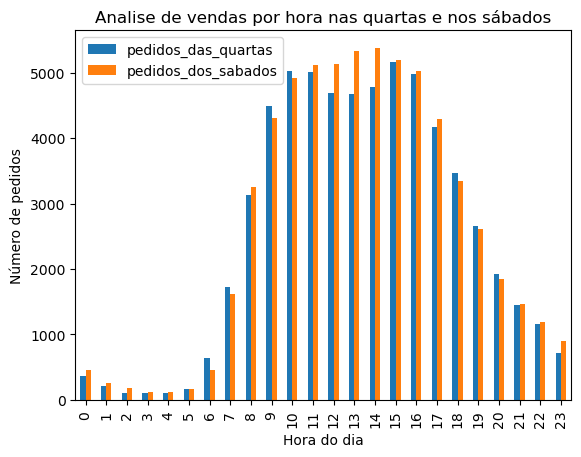

In [43]:
print("OBS: Veja que, no enunciado acima foi pedido para criar um gráfico de barras")
# Por fim, farei o gráfico de barras pedido:
horas_quarta_sabado.plot(
    title = "Analise de vendas por hora nas quartas e nos sábados",
    x = 'hora_do_dia',
    y = ['pedidos_das_quartas','pedidos_dos_sabados'],
    xlabel = "Hora do dia",
    ylabel = "Número de pedidos",
    kind = 'bar'
    
)

plt.show()


conclusões:

Existe uma diferença notória entre as 12h e 14h. Os sábados mostram-se bem mais lucrativos que as quartas nesses horários.

### [B2] Qual é a distribuição do número de pedidos por cliente?

In [44]:
# Agrupando os pedidos pelos clientes
pedidos_por_cliente = orders.groupby('user_id')['order_id'].count().reset_index()
# renomeando as colunas:
cols = {'user_id': 'cliente_id','order_id':'quantidade_de_pedidos'}
pedidos_por_cliente = pedidos_por_cliente.rename(columns = cols)
print(pedidos_por_cliente)

        cliente_id  quantidade_de_pedidos
0                2                      2
1                4                      2
2                5                      1
3                6                      2
4                7                      2
...            ...                    ...
157432      206203                      1
157433      206206                      7
157434      206207                      5
157435      206208                      9
157436      206209                      2

[157437 rows x 2 columns]


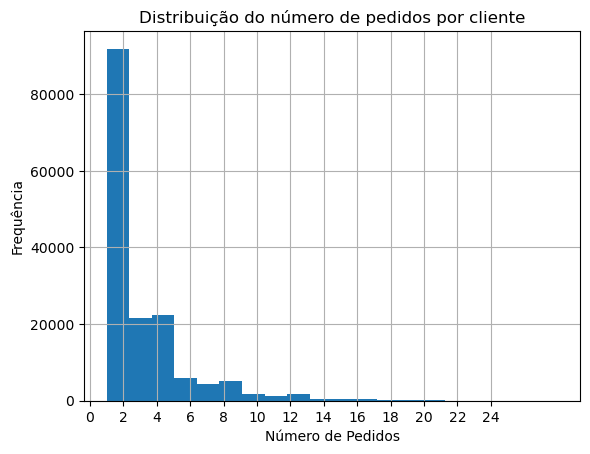

In [45]:
# Criando um histograma com base na distribuição da quantidade de pedidos por cliente:
pedidos_por_cliente.hist(column = 'quantidade_de_pedidos', bins = 20)
plt.xlabel('Número de Pedidos')
plt.ylabel('Frequência')
plt.title('Distribuição do número de pedidos por cliente')
plt.xticks(range(0, 25, 2)) # Adicionando mais rótulos no eixo x   
plt.show()

conclusões:

A grande maioria dos clientes fazem até 5 pedidos. E a maior parte deles (moda) fazem até 3 pedidos.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [46]:
# Agrupando pedidos por ID de produto:
pedidos_por_produto_id = order_products.groupby('product_id')['order_id'].count().reset_index()
# renomeando as colunas de 'pedidos_por_produto_id':
cols = {'product_id':'product_id','order_id':'pedidos'}
pedidos_por_produto_id = pedidos_por_produto_id.rename(columns = cols)

# Indexando colunas 'product_id' e 'product_name' de 'products' em um novo dataframe:
produtos_e_produto_id = products[['product_id','product_name']]

In [47]:
# convertendo os dados da coluna 'products_id' para o tipo objeto (string) nos dataframes 'pedidos_por_produto_id' e 'produtos_e_produto_id':

pedidos_por_produto_id['product_id'] = pedidos_por_produto_id['product_id'].astype('str')
produtos_e_produto_id['product_id'] = produtos_e_produto_id['product_id'].astype('str')

#  Juntando, internamente, 'pedidos_por_produto_id' com 'produtos_e_produto_id' atravéz da coluna 'product_id', e salvando o resultado no DataFrame 'produtos_vencedores':
produtos_vencedores = pedidos_por_produto_id.merge(
    produtos_e_produto_id,
    on = 'product_id'
)

# ordenando 'produtos_vencedores' pela coluna 'pedidos', em ordem decrescente:
produtos_vencedores = produtos_vencedores.sort_values(by = 'pedidos', ascending = False).reset_index(drop=True)

# Extraindo os 20 produtos mais populares de 'produtos_vencedores', e armazenando no Dataframe 'top_20_produtos_vencedores'
top_20_produtos_vencedores = produtos_vencedores[0:20]

# Exibindo os IDs e nomes desses produtos:
print(top_20_produtos_vencedores[['product_id','product_name']])

   product_id              product_name
0       24852                    banana
1       13176    bag of organic bananas
2       21137      organic strawberries
3       21903      organic baby spinach
4       47209      organic hass avocado
5       47766           organic avocado
6       47626               large lemon
7       16797              strawberries
8       26209                     limes
9       27845        organic whole milk
10      27966       organic raspberries
11      22935      organic yellow onion
12      24964            organic garlic
13      45007          organic zucchini
14      39275       organic blueberries
15      49683            cucumber kirby
16      28204        organic fuji apple
17       5876             organic lemon
18       8277  apple honeycrisp organic
19      40706    organic grape tomatoes


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_12540\2633942868.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  produtos_e_produto_id['product_id'] = produtos_e_produto_id['product_id'].astype('str')


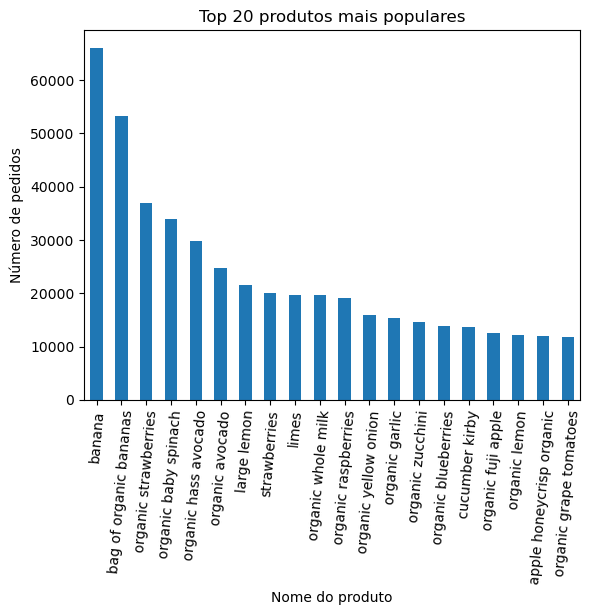

In [48]:
# exibindo as vendas por produto em um gráfico de barras:
top_20_produtos_vencedores.plot(
    title = "Top 20 produtos mais populares",
    kind = 'bar',
    x = 'product_name',
    y = 'pedidos',
    xlabel = 'Nome do produto',
    ylabel = 'Número de pedidos',
    rot = 85,
    legend = False
)
plt.show()

conclusões:

Grande maioria dos 20 produtos mais populares são produtos orgânicos

### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [49]:
# devemos agrupar os IDs dos produtos por pedido em 'order_products':
itens_por_pedido = order_products.groupby('order_id')['product_id'].count().reset_index()

print(itens_por_pedido)

        order_id  product_id
0              4          13
1              9          15
2             11           5
3             19           3
4             20           8
...          ...         ...
450041   3421034          17
450042   3421053           9
450043   3421071           5
450044   3421077           4
450045   3421079           1

[450046 rows x 2 columns]


In [50]:
# Valor mais comum (moda):
valor_mais_comum = itens_por_pedido['product_id'].mode()[0]
print(f'As pessoas normalmente compram {valor_mais_comum} itens por pedido')

As pessoas normalmente compram 5 itens por pedido


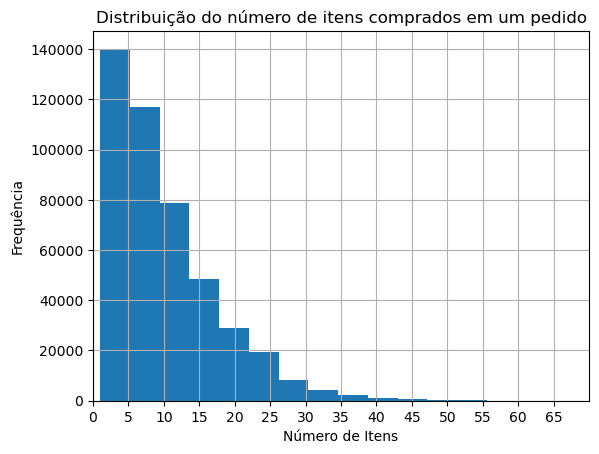

In [51]:
# distribuição:
itens_por_pedido.hist(column = 'product_id', bins = 30)
plt.xlabel('Número de Itens')
plt.ylabel('Frequência')
plt.title('Distribuição do número de itens comprados em um pedido')
plt.xlim(0, 70)
plt.xticks(range(0, 70, 5)) # Adicionando mais rótulos no eixo x   
plt.show()

conclusões:

5 itens por pedido é a moda. Enquanto a maioria da amostra compram até 15 itens por pedido. 

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [52]:
# Filtrando apenas as linhas dos produtos já comprados em 'order_products':
ja_comprados = order_products[order_products['reordered'] == 1]

In [53]:
# Agrupando 'ja_comprados' para obter os agrupamentos da frequência de compra com relação a 'product_id':
repeticao_por_produto = ja_comprados.groupby('product_id')['reordered'].count().reset_index()

# Indexando 'product_id' e 'product_name' de 'products' e salvando em um novo dataframe:
product_id_product_name = products[['product_id','product_name']]
print(product_id_product_name)

      product_id                                       product_name
0              1                         chocolate sandwich cookies
1              2                                   all-seasons salt
2              3               robust golden unsweetened oolong tea
3              4  smart ones classic favorites mini rigatoni wit...
4              5                          green chile anytime sauce
...          ...                                                ...
49689      49690                      high performance energy drink
49690      49691                      original pancake & waffle mix
49691      49692    organic instant oatmeal light maple brown sugar
49692      49693                             spring water body wash
49693      49694                            burrito- steak & cheese

[49694 rows x 2 columns]


In [54]:
# convertendo os dados da coluna 'products_id' para o tipo objeto (string) nos dataframes 'repeticao_por_produto' e 'product_id_product_name':
repeticao_por_produto['product_id'] = repeticao_por_produto['product_id'].astype(str)
product_id_product_name['product_id'] = product_id_product_name['product_id'].astype(str)

# Juntando 'repeticao_por_produto' com 'product_id_product_name' em um novo dataframe:
frequencia_de_inclusoes_repetidas = repeticao_por_produto.merge(
    product_id_product_name,
    on = 'product_id'
)

# Ordenando em ordem decrescente e selecionando os 20 primeiros colocados em um novo DataFrame:
frequencia_de_inclusoes_repetidas = frequencia_de_inclusoes_repetidas.sort_values(by = 'reordered', ascending = False).reset_index(drop=True)
top_20_inclusoes_repetidas = frequencia_de_inclusoes_repetidas[0:20]

# Imprimindo os IDs e nomes:
print(top_20_inclusoes_repetidas[['product_id','product_name']])

   product_id              product_name
0       24852                    banana
1       13176    bag of organic bananas
2       21137      organic strawberries
3       21903      organic baby spinach
4       47209      organic hass avocado
5       47766           organic avocado
6       27845        organic whole milk
7       47626               large lemon
8       27966       organic raspberries
9       16797              strawberries
10      26209                     limes
11      22935      organic yellow onion
12      24964            organic garlic
13      45007          organic zucchini
14      49683            cucumber kirby
15      28204        organic fuji apple
16       8277  apple honeycrisp organic
17      39275       organic blueberries
18       5876             organic lemon
19      49235       organic half & half


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_12540\3704238843.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_id_product_name['product_id'] = product_id_product_name['product_id'].astype(str)


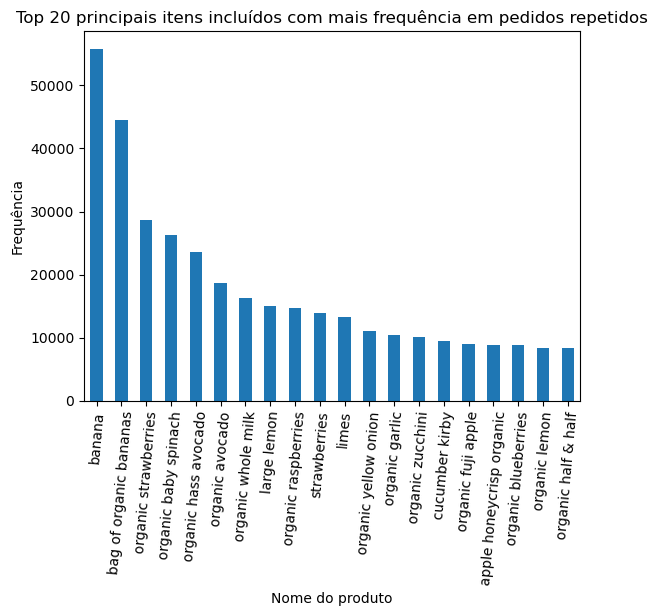

In [55]:
# Fazendo um gráfico de barras para melhor ilustrar:
top_20_inclusoes_repetidas.plot(
    title = "Top 20 principais itens incluídos com mais frequência em pedidos repetidos",
    kind = 'bar',
    x = 'product_name',
    y = 'reordered',
    xlabel = 'Nome do produto',
    ylabel = 'Frequência',
    rot = 85,
    legend = False
)

plt.show()

conclusões:

Esse gráfico mostra bem a distribuição que queriamos

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [56]:
# indexando as colunas 'product_id' e 'product_name' de 'products', e 'product_id' e 'reordered' de 'order_products', e armazenando os resultados em novos dataframes:
data_product_name = products[['product_id','product_name']]
data_reordered = order_products[['product_id','reordered']]

# Converte a coluna 'product_id' para string em ambos os DataFrames (se necessário)
data_reordered['product_id'] = data_reordered['product_id'].astype('str')
data_product_name['product_id'] = data_product_name['product_id'].astype('str')

# Juntando internamente as duas tabelas indexadas:
produtos_e_repeticoes = data_reordered.merge(
    data_product_name,
    on = 'product_id',
)

print(produtos_e_repeticoes)

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_12540\2701839946.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_reordered['product_id'] = data_reordered['product_id'].astype('str')
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_12540\2701839946.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_product_name['product_id'] = data_product_name['product_id'].astype('str')


        product_id  reordered  \
0            11440          0   
1             1560          1   
2            26683          1   
3             8670          1   
4             1940          1   
...            ...        ...   
4542052      15290          1   
4542053      21914          0   
4542054      47766          1   
4542055        691          1   
4542056      28733          0   

                                              product_name  
0                           chicken breast tenders breaded  
1                                               bag of ice  
2        cafe latte pure lightly sweetened iced coffee ...  
3                                           diced tomatoes  
4                              organic 2% reduced fat milk  
...                                                    ...  
4542052                                 orange bell pepper  
4542053         peanut butter & jelly fruit & nut food bar  
4542054                                    organic avo

In [57]:
# Engenharia de característica:
# Essa funçao inverte o 0 e o 1 da coluna 'reordered':
def f_0 (x):
    if x == 0:
        return 1
    else:
        return 0
# Criando uma nova coluna 'reordered_reverse' para contar os valores 0 futuramente:
produtos_e_repeticoes['reordered_reverse'] = produtos_e_repeticoes['reordered'].apply(f_0)

# A idéia é simples: 'reordered' contará a quantidade de produtos já comprados antes (1), enquanto 'reordered_reverse' contará a quantidade de produtos nunca comprados (0), para cada 'product_id'
# Vamos agrupar para fazer essa contage, então:
produtos_comprados_antes = produtos_e_repeticoes.groupby('product_id')['reordered'].sum().reset_index()
produtos_nunca_comprados = produtos_e_repeticoes.groupby('product_id')['reordered_reverse'].sum().reset_index()
# Agora, vamos junta-los:
produtos_compras = produtos_comprados_antes.merge(
    produtos_nunca_comprados,
    on = 'product_id'
)

# vamos criar uma coluna chamada 'proporção':
produtos_compras['proporcao'] = produtos_compras['reordered']/(produtos_compras['reordered_reverse'] + produtos_compras['reordered'])
print(produtos_compras)

# Vamos agora indexar as colunas 'product_id' e 'proporcao' em um novo Dataframe:
product_id_proporcao = produtos_compras[['product_id','proporcao']]

      product_id  reordered  reordered_reverse  proporcao
0              1        158                122   0.564286
1             10        151                186   0.448071
2            100         39                 22   0.639344
3           1000        163                227   0.417949
4          10000          3                  1   0.750000
...          ...        ...                ...        ...
45455       9993          0                  6   0.000000
45456       9995         14                 15   0.482759
45457       9996         38                130   0.226190
45458       9997          2                  5   0.285714
45459       9999          0                  1   0.000000

[45460 rows x 4 columns]


      product_id  proporcao                                    product_name
0              1   0.564286                      chocolate sandwich cookies
1             10   0.448071  sparkling orange juice & prickly pear beverage
2            100   0.639344         peanut butter & strawberry jam sandwich
3           1000   0.417949                                        apricots
4          10000   0.750000                   refresher strawberry lemonade
...          ...        ...                                             ...
45455       9993   0.000000                    organic french green lentils
45456       9995   0.482759               sesame seed new york style bagels
45457       9996   0.226190                           less sodium soy sauce
45458       9997   0.285714                        italian style vegetables
45459       9999   0.000000        cheese- spreadable- crescenza-stracchino

[45460 rows x 3 columns]


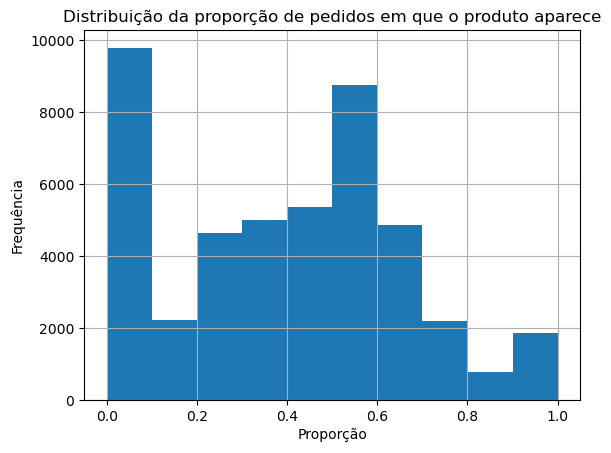

In [58]:
# Vamos juntar 'product_id_proporcao' com 'data_product_name':
produto_e_proporcao = product_id_proporcao.merge(
    data_product_name,
    on = 'product_id'
)
print(produto_e_proporcao)# Essa é a tabela pedida no exercício

# Histograma de distribuição da proporção:
produto_e_proporcao.hist(column ='proporcao', bins = 10)
plt.xlabel('Proporção')
plt.ylabel('Frequência')
plt.title('Distribuição da proporção de pedidos em que o produto aparece')

plt.show()

conclusões:

A moda está entre 0 e 0,2 de proporção. Mas um grande volume bem próximo da moda encontra-se entre 0,5 e 0,6 de proporção

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [59]:
# precisamos ter as informações 'reordered' e 'user_id' em uma mesma tabela pra fazer isso:
usuario_e_id = orders[['order_id','user_id']]
reordered_e_id = order_products[['order_id','reordered']]
# juntando as tabelas pela coluna 'order_id':
usuario_id_reordered = usuario_e_id.merge(
    reordered_e_id,
    on = 'order_id'
) # Pronto, agora temos o que queriamos: 'reordered' e 'user_id' em uma mesma tabela

# Agora, vamos calcular o número de pedidos total e repetidos, para cada usuário:
usuario_total = usuario_id_reordered.groupby('user_id')['order_id'].count().reset_index()
usuario_repetidos = usuario_id_reordered.groupby('user_id')['reordered'].sum().reset_index()

# vamos juntar os dois:
usuario_total_repetido = usuario_total.merge(
    usuario_repetidos,
    on = 'user_id'
)

usuario_total_repetido = usuario_total_repetido.rename(columns = {'order_id': 'total' , 'user_id':'user_id' , 'reordered':'repetidos'})

print(usuario_total_repetido.head())

   user_id  total  repetidos
0        2     26          1
1        4      2          0
2        5     12          8
3        6      4          0
4        7     14         13


        user_id  total  repetidos  proporcao
0             2     26          1   0.038462
1             4      2          0   0.000000
2             5     12          8   0.666667
3             6      4          0   0.000000
4             7     14         13   0.928571
...         ...    ...        ...        ...
149621   206203     27          6   0.222222
149622   206206     21         15   0.714286
149623   206207     46         41   0.891304
149624   206208    125         87   0.696000
149625   206209     25          8   0.320000

[149626 rows x 4 columns]


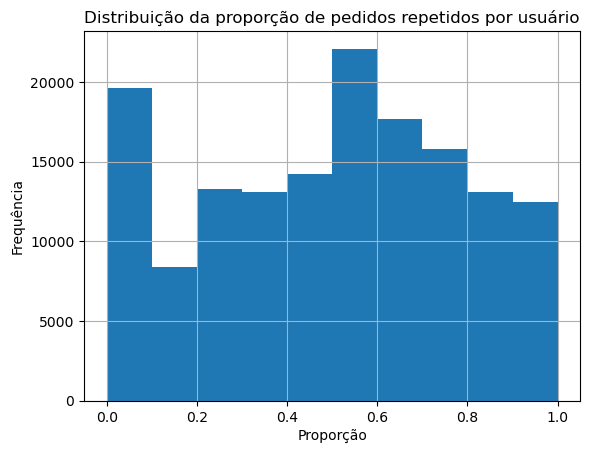

In [60]:
# Vamos adicionar a coluna 'proporção':
usuario_total_repetido['proporcao'] = usuario_total_repetido['repetidos']/usuario_total_repetido['total']
print(usuario_total_repetido)

# Histograma:
usuario_total_repetido.hist(column ='proporcao', bins = 10)
plt.xlabel('Proporção')
plt.ylabel('Frequência')
plt.title('Distribuição da proporção de pedidos repetidos por usuário')

plt.show()

conclusões:

A moda está estre 0,5 e 0,6 de proporção.

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [61]:
# temos que filtrar 'order_products' com os valores da coluna 'add_to_cart_order' iguais a 1:
adicionado_primeiro = order_products[order_products['add_to_cart_order'] == 1]

# indexaremos 'products' por 'product_id' e 'product_name':
peoduct_id_e_name = products[['product_id','product_name']]

# contando quantas vezes cada produto foi adicionado primeiro ao carrinho:
quantidade_adicoes = adicionado_primeiro.groupby('product_id')['add_to_cart_order'].count().reset_index()

# renomeando colunas
cols = {'product_id':'product_id' ,'add_to_cart_order':'numero_de_adicoes_em_primeiro'}
quantidade_adicoes = quantidade_adicoes.rename(columns = cols)

In [62]:
# convertendo os dados da coluna 'products_id' para o tipo objeto (string) nos dataframes 'quantidade_adicoes' e 'peoduct_id_e_name':
quantidade_adicoes['product_id'] = quantidade_adicoes['product_id'].astype('str')
peoduct_id_e_name['product_id'] = peoduct_id_e_name['product_id'].astype('str')

# por fim, vamos juntar 'quantidade_adicoes' com 'peoduct_id_e_name', ordenar e filtrar os 20 primeiros dados:
adicionado_primeiro_completo = quantidade_adicoes.merge(
    peoduct_id_e_name,
    on = 'product_id'
).sort_values(by = 'numero_de_adicoes_em_primeiro', ascending = False).reset_index(drop=True)

adicionado_primeiro_completo = adicionado_primeiro_completo[0:20]

print(adicionado_primeiro_completo)

   product_id  numero_de_adicoes_em_primeiro                 product_name
0       24852                          15562                       banana
1       13176                          11026       bag of organic bananas
2       27845                           4363           organic whole milk
3       21137                           3946         organic strawberries
4       47209                           3390         organic hass avocado
5       21903                           3336         organic baby spinach
6       47766                           3044              organic avocado
7       19660                           2336                 spring water
8       16797                           2308                 strawberries
9       27966                           2024          organic raspberries
10      44632                           1914   sparkling water grapefruit
11      49235                           1797          organic half & half
12      47626                         

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_12540\3187987916.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peoduct_id_e_name['product_id'] = peoduct_id_e_name['product_id'].astype('str')


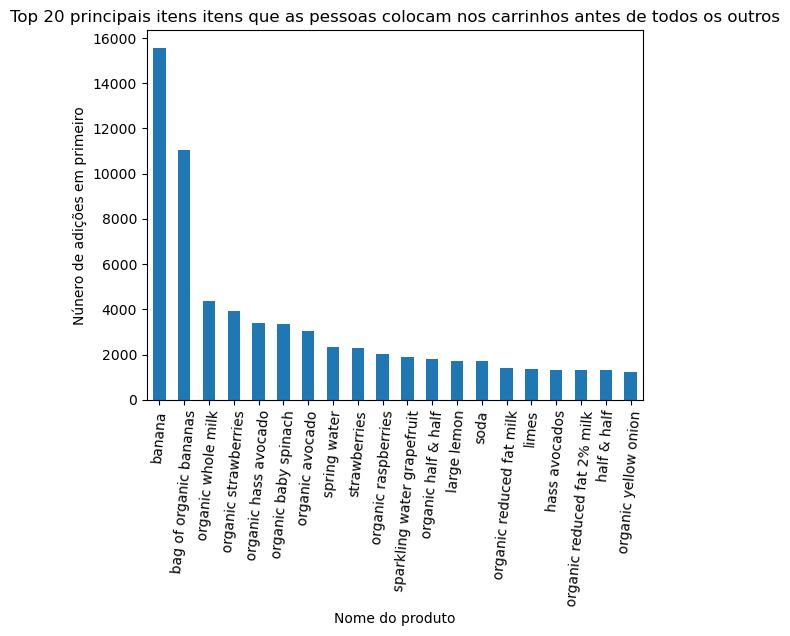

In [63]:
# Criando um gráfico de barras para os dados:
adicionado_primeiro_completo.plot(
    title = "Top 20 principais itens itens que as pessoas colocam nos carrinhos antes de todos os outros",
    kind = 'bar',
    x = 'product_name',
    y = 'numero_de_adicoes_em_primeiro',
    xlabel = 'Nome do produto',
    ylabel = 'Núnero de adições em primeiro',
    rot = 85,
    legend = False
)

plt.show()

conclusões:

Esse gráfico resume bem o nosso resultado

# Conclusão geral do projeto:

A partir das análises dos dados, podemos concluir os seguintes pontos importantes:
# 1.Resumo dos Principais Achados:
- A grande maioria dos usuários compram entre as 9 horas da manhã e as 16 horas da tarde.
- Os top produtos mais recomprados são: banana, bag of organic bananas, organic strawberries, organic baby spinach, organic hass avocado organic avocado, large lemon, strawberries, limes, organic whole milk, organic raspberries, organic yellow onion, organic garlic, organic zucchini, organic blueberries, cucumber kirby, organic fuji apple, organic lemon, apple honeycrisp organic, e organic grape tomatoes.
- A maioria dos usuários tem proporção de recompra entre 50% e 60%
- Domingo e Segunda são os dias da semana em que as pessoas mais compram produtos alimentícios.
- Encontramos também os Top 20 principais itens incluídos com mais frequência em pedidos repetidos.
- E também obtivemos os Top 20 principais itens itens que as pessoas colocam nos carrinhos antes de todos os outros.
# 2.Insights de Negócio:
- Fidelidade do cliente: Alta taxa de recompra indica satisfação.
- Produtos essenciais: Itens básicos (leite, pão, frutas) dominam recompras.
- Oportunidade: Focar marketing nos produtos com baixa recompra.
- Os principais itens incluídos com mais frequência em pedidos repetidos encontrados são considerados de 'âncora' ou 'magnéticos', podendo ser usados como isca para atrair a primeira compra em campanhas futuras. 

# 3.Recomendações Rápidas:
- Criar campanhas para produtos com baixa recompra
- Otimizar estoque dos produtos mais recomprados
- Desenvolver programa de fidelidade baseado em padrões de recompra
# 4.Limitações:
Esta análise considera apenas dados históricos e não fatores externos como sazonalidade ou promoções.